Raw file content:
 	2V_10T	2V_10T	2V_16T	2V_16T	2V_28T	2V_28T	3V_15T	3V_15T	4V_16T	4V_16T	4V_20T	4V_20T	5V_15T	5V_15T
sweeps	SA	DA	SA	DA	SA	DA	SA	DA	SA	DA	SA	DA	SA	DA
10	18.98	72.41	33.64	120.06	64.78	135.98	42.24	96.65	61.43	137.68	81.4	144.02	71.77	186.14
50	65.48	165.42	116.3	197.95	305.13	296.21	164.32	359.28	241.3	375.54	334.27	396.13	282.88	476.21
100	120.98	263.49	220.9	319.38	499.25	416.44	315.21	547.4	463.22	606.91	630.99	641.83	588.29	818.53
150	178.75	372.32	325.32	404.91	739.68	538.05	460.8	623	686.12	815.57	933.18	902.32	843.97	1078.51
Headers:
 [[nan '2V_10T' '2V_10T' '2V_16T' '2V_16T' '2V_28T' '2V_28T' '3V_15T'
  '3V_15T' '4V_16T' '4V_16T' '4V_20T' '4V_20T' '5V_15T' '5V_15T']
 ['sweeps' 'SA' 'DA' 'SA' 'DA' 'SA' 'DA' 'SA' 'DA' 'SA' 'DA' 'SA' 'DA'
  'SA' 'DA']]
Data shape: (4, 15)
Data content:
 [[  10.     18.98   72.41   33.64  120.06   64.78  135.98   42.24   96.65
    61.43  137.68   81.4   144.02   71.77  186.14]
 [  50.     65.48  165.42  116.3   197.95  305.13  296.

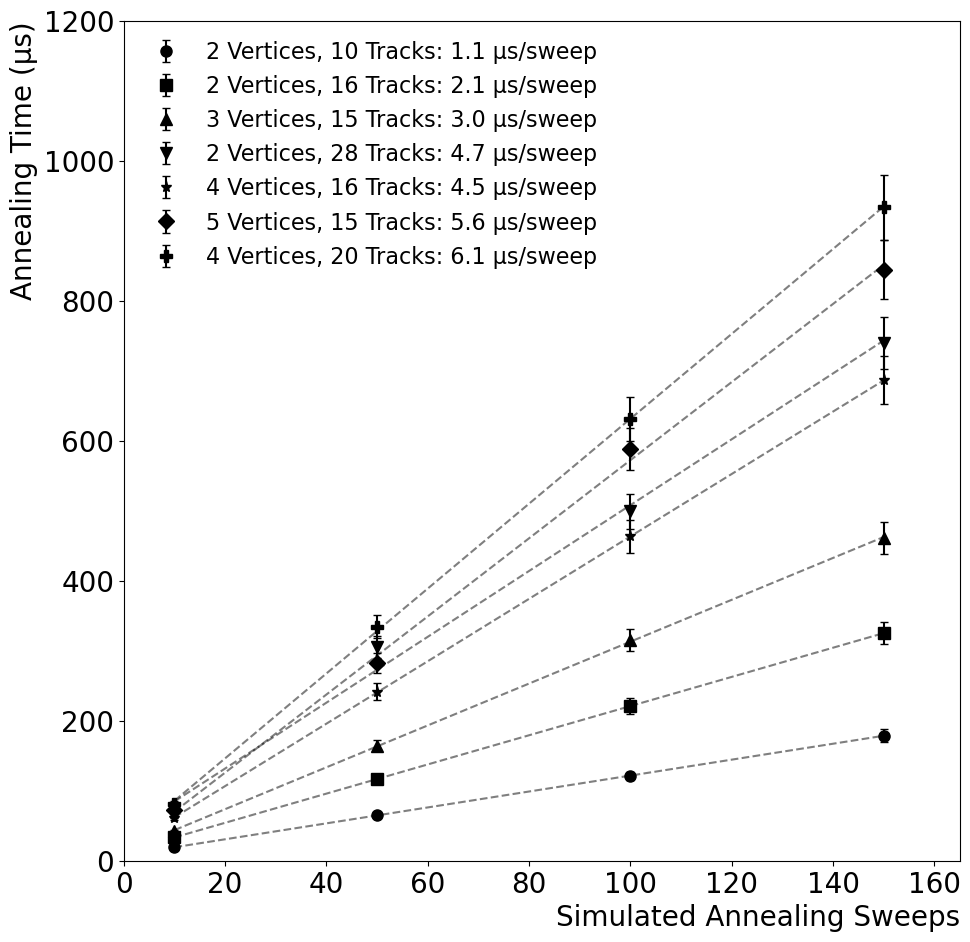

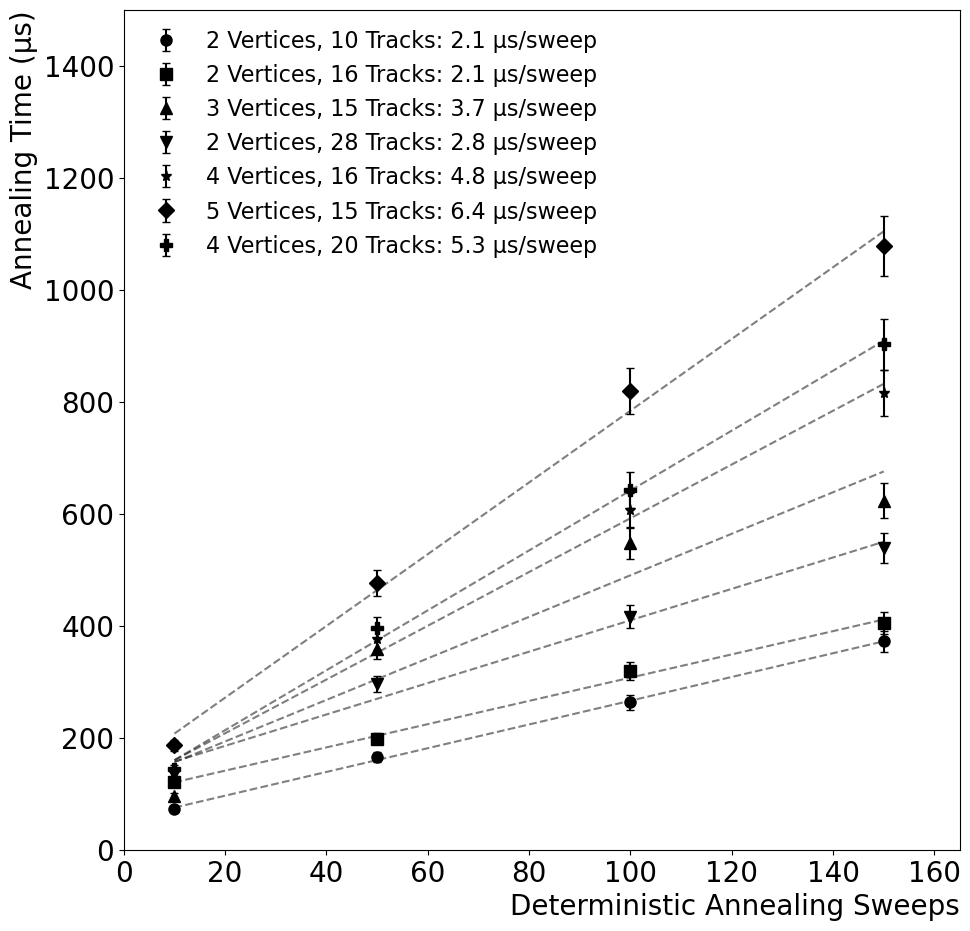


DataFrame:
                     0   1   2   3      4   5         6         7          8   \
0   5Vertices_15Tracks  SA   1   1  10000  14  0.786943  0.077551   0.380225   
1   5Vertices_15Tracks  DA   1   1  10000  12  0.954232  0.023830   3.431293   
2   5Vertices_15Tracks  QA   1   1  10000  14  0.069501  0.009714   0.396931   
3   4Vertices_20Tracks  SA   1   1  10000  13  0.621720  0.024448   0.615482   
4   4Vertices_20Tracks  DA   1   1  10000  15  0.970617  0.018356   3.060829   
5   4Vertices_20Tracks  QA   1   1  10000  13  0.102306  0.008947   0.700302   
6   4Vertices_16Tracks  SA   1   1  10000  17  0.855552  0.024820   0.376630   
7   4Vertices_16Tracks  DA   1   1  10000  16  0.988235  0.010090   5.997627   
8   4Vertices_16Tracks  QA   1   1  10000  17  0.295097  0.029177   0.446468   
9   3Vertices_15Tracks  SA   1   1  10000  15  0.755929  0.008812   1.114373   
10  3Vertices_15Tracks  DA   1   1  10000  12  0.988235  0.009873   3.566659   
11  3Vertices_15Tracks  QA 

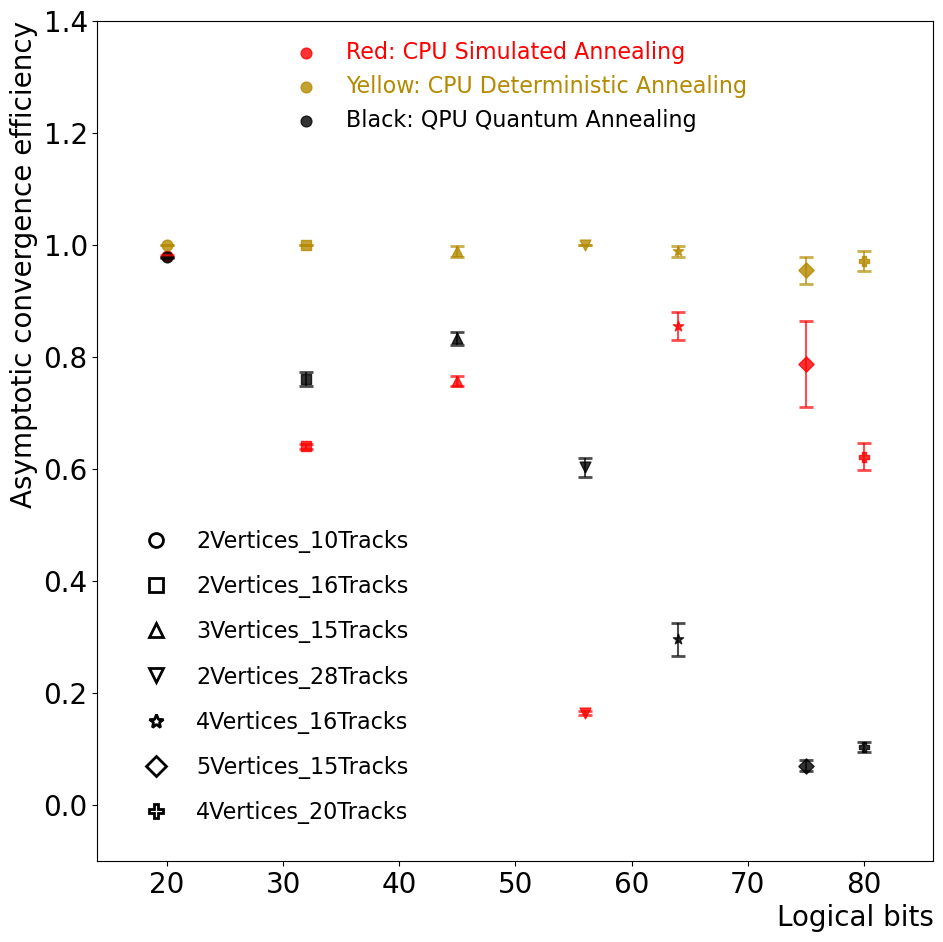

C:\Users\Sachin\AppData\Local\Temp\ipykernel_15060\2680825305.py:420: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(logistic_4p, x_data, y_data, p0=p0, bounds=bounds, maxfev=50000)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


5Vertices_15Tracks, SA
5Vertices_15Tracks, DA
5Vertices_15Tracks, SA
5Vertices_15Tracks, DA
5Vertices_15Tracks, SA
5Vertices_15Tracks, DA
5Vertices_15Tracks, SA
5Vertices_15Tracks, DA
4Vertices_20Tracks, SA
4Vertices_20Tracks, DA
4Vertices_20Tracks, SA
4Vertices_20Tracks, DA
4Vertices_20Tracks, SA
4Vertices_20Tracks, DA
4Vertices_20Tracks, SA
4Vertices_20Tracks, DA
4Vertices_16Tracks, SA
4Vertices_16Tracks, DA
4Vertices_16Tracks, SA
4Vertices_16Tracks, DA
4Vertices_16Tracks, SA
4Vertices_16Tracks, DA
4Vertices_16Tracks, SA
4Vertices_16Tracks, DA
3Vertices_15Tracks, SA
3Vertices_15Tracks, DA
3Vertices_15Tracks, SA
3Vertices_15Tracks, DA
3Vertices_15Tracks, SA
3Vertices_15Tracks, DA
3Vertices_15Tracks, SA
3Vertices_15Tracks, DA
2Vertices_28Tracks, SA
2Vertices_28Tracks, DA
2Vertices_28Tracks, SA
2Vertices_28Tracks, DA
2Vertices_28Tracks, SA
2Vertices_28Tracks, DA
2Vertices_28Tracks, SA
2Vertices_28Tracks, DA
2Vertices_16Tracks, SA
2Vertices_16Tracks, DA
2Vertices_16Tracks, SA
2Vertices_1

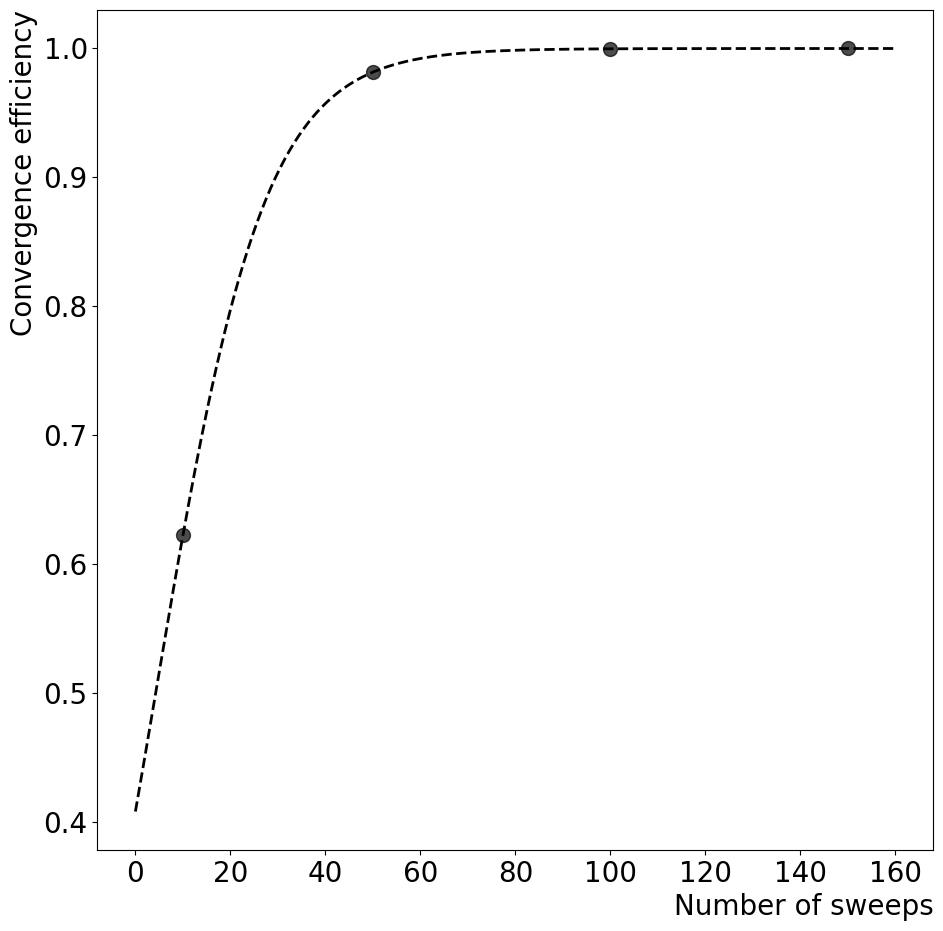

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
import pandas as pd

error_factor = 0.05

# Print raw file content for debugging
try:
    with open('SachinPCAnnealTime_vs_Sweeps.txt', 'r') as f:
        print("Raw file content:\n", f.read())
except Exception as e:
    print(f"Error reading file: {e}")
    exit()

# Read header rows
try:
    header_df = pd.read_csv('SachinPCAnnealTime_vs_Sweeps.txt', nrows=2, header=None, sep='\t')
    headers = header_df.values
    print("Headers:\n", headers)
except Exception as e:
    print(f"Error reading headers: {e}")
    exit()

# Read data with pandas (tab-delimited), starting from third row (index 2)
try:
    data_df = pd.read_csv('SachinPCAnnealTime_vs_Sweeps.txt', skiprows=2, sep='\t', header=None)
    data = data_df.to_numpy()
    print("Data shape:", data.shape)
    print("Data content:\n", data)
except Exception as e:
    print(f"Error reading data with pandas: {e}")
    # Fallback to genfromtxt
    try:
        data = np.genfromtxt('SachinPCAnnealTime_vs_Sweeps.txt', skip_header=2, delimiter='\t', filling_values=np.nan)
        print("Data shape (genfromtxt):", data.shape)
        print("Data content (genfromtxt):\n", data)
    except Exception as e2:
        print(f"Error reading data with genfromtxt: {e2}")
        exit()

# Validate data shape
if data.ndim != 2 or data.shape[1] < 2:
    print(f"Error: Data is not a valid 2D array with multiple columns. Shape: {data.shape}")
    exit()
if np.any(np.isnan(data)):
    print("Warning: Data contains NaN values. They will be handled during plotting.")

# Identify SA/DA columns
sa_columns = [i for i, label in enumerate(headers[1, 1:], start=1) if label == 'SA']
da_columns = [i for i, label in enumerate(headers[1, 1:], start=1) if label == 'DA']
print("SA Columns (1-based indices):", sa_columns)
print("DA Columns (1-based indices):", da_columns)

# Extract data
x = data[:, 0]  # Sweeps
y_columns_sa = data[:, sa_columns] if sa_columns else np.array([])
y_columns_da = data[:, da_columns] if da_columns else np.array([])
print("x shape:", x.shape)
print("y_columns_sa shape:", y_columns_sa.shape)
print("y_columns_da shape:", y_columns_da.shape)

print(f"x: {x}")
print(f"y_columns_sa: {y_columns_sa}")
print(f"y_columns_da: {y_columns_da}")

# Legend labels
legend_labels_sa = headers[0, sa_columns] if sa_columns else []
legend_labels_da = headers[0, da_columns] if da_columns else []
print("SA Legend Labels:", legend_labels_sa)
print("DA Legend Labels:", legend_labels_da)

def extract_product(label):
    """Extract n * t from label like 'nV_tT'."""
    parts = label.split('_')
    n_str = parts[0][:-1]  # Remove 'V'
    t_str = parts[1][:-1]  # Remove 'T'
    n = int(n_str)
    t = int(t_str)
    return n * t

sorted_indices = sorted(range(len(legend_labels_sa)), key=lambda i: extract_product(legend_labels_sa[i]))
legend_labels_sa_sorted = [legend_labels_sa[i] for i in sorted_indices]
legend_labels_da_sorted = [legend_labels_da[i] for i in sorted_indices]
y_columns_sa_sorted = [[row[i] for i in sorted_indices] for row in y_columns_sa]
y_columns_da_sorted = [[row[i] for i in sorted_indices] for row in y_columns_da]

legend_labels_sa = legend_labels_sa_sorted
legend_labels_da = legend_labels_da_sorted

y_columns_sa = np.array(y_columns_sa_sorted)
y_columns_da = np.array(y_columns_da_sorted)

print(f"y_columns_sa: {y_columns_sa}")

# Markers and colors
markers = ['o', 's', '^', 'v', '*', 'D', 'P']
colors = ['black'] * len(markers)

# Confidence interval function
def confidence_interval(x, y, slope, intercept, confidence=0.95):
    from scipy.stats import t
    n = len(x)
    y_fit = slope * x + intercept
    residuals = y - y_fit
    s = np.sqrt(np.sum(residuals**2) / (n - 2))
    t_val = t.ppf((1 + confidence) / 2, n - 2)
    x_mean = np.mean(x)
    x_diff = x - x_mean
    se_fit = s * np.sqrt(1/n + x_diff**2 / np.sum(x_diff**2))
    ci = t_val * se_fit
    return y_fit - ci, y_fit + ci

# Plot SA
plt.figure(figsize=(11, 10))
if y_columns_sa.size > 0:
    for i in range(y_columns_sa.shape[1]):
        y = y_columns_sa[:, i]
        valid_mask = ~np.isnan(y) & ~np.isnan(x)  # Mask for valid data points
        if np.sum(valid_mask) < 2:  # Need at least 2 points for regression
            print(f"Warning: Insufficient valid data in SA column {i}")
            continue
        x_valid = x[valid_mask]
        y_valid = y[valid_mask]
        slope, intercept, _, _, slope_stderr = linregress(x_valid, y_valid)
        y_fit = slope * x + intercept
        residuals = y_valid - (slope * x_valid + intercept)
        #y_err = np.std(residuals) * np.ones_like(y_valid)
        y_err = y_valid * error_factor
        plt.errorbar(x_valid, y_valid, yerr=y_err, fmt=markers[i % len(markers)], color=colors[i % len(colors)], 
                     label=f'{legend_labels_sa[i].replace("V_"," Vertices, ").replace("T", " Tracks")}: {slope:.1f} µs/sweep', 
                     capsize=3, markersize=8, ecolor='black')
        plt.plot(x, y_fit, '--', color='black', alpha=0.5)
        ci_lower, ci_upper = confidence_interval(x_valid, y_valid, slope, intercept)
        #plt.fill_between(x, ci_lower, ci_upper, color='black', alpha=0.1)
else:
    print("No SA columns to plot")
    plt.text(0.5, 0.5, "No SA data available", ha='center', va='center')

plt.xlabel('Simulated Annealing Sweeps', loc='right', fontsize=20)
plt.ylabel('Annealing Time (µs)', loc='top', fontsize=20)
#plt.xticks(fontsize=20)
#plt.yticks(fontsize=20)
plt.tick_params(axis='x', which='both', labelsize=20)
plt.tick_params(axis='y', which='both', labelsize=20)
#plt.title('SA: Scatter Plot with Linear Fit and Error Bars')
handles, labels = plt.gca().get_legend_handles_labels()
if labels:
    plt.legend(handles, labels, fontsize=16, frameon=False)
else:
    print("Warning: No valid labels for SA plot")
plt.grid(False)
plt.xlim(0, 165)
plt.ylim(0, 1200)
#plt.ylim(auto=True)
plt.tight_layout()
plt.subplots_adjust(left=0.12, bottom=0.08, right=0.88, top=0.92)
plt.savefig('SachinPCscatter_plot_sa.png')
plt.show()

# Plot DA
plt.figure(figsize=(11, 10))
if y_columns_da.size > 0:
    for i in range(y_columns_da.shape[1]):
        y = y_columns_da[:, i]
        valid_mask = ~np.isnan(y) & ~np.isnan(x)  # Mask for valid data points
        if np.sum(valid_mask) < 2:  # Need at least 2 points for regression
            print(f"Warning: Insufficient valid data in DA column {i}")
            continue
        x_valid = x[valid_mask]
        y_valid = y[valid_mask]
        slope, intercept, _, _, slope_stderr = linregress(x_valid, y_valid)
        y_fit = slope * x + intercept
        residuals = y_valid - (slope * x_valid + intercept)
        #y_err = np.std(residuals) * np.ones_like(y_valid)
        y_err = y_valid * error_factor
        plt.errorbar(x_valid, y_valid, yerr=y_err, fmt=markers[i % len(markers)], color=colors[i % len(colors)], 
                     label=f'{legend_labels_da[i].replace("V_"," Vertices, ").replace("T", " Tracks")}: {slope:.1f} µs/sweep', 
                     capsize=3, markersize=8, ecolor='black')
        plt.plot(x, y_fit, '--', color='black', alpha=0.5)
        ci_lower, ci_upper = confidence_interval(x_valid, y_valid, slope, intercept)
        #plt.fill_between(x, ci_lower, ci_upper, color='black', alpha=0.1)
else:
    print("No DA columns to plot")
    plt.text(0.5, 0.5, "No DA data available", ha='center', va='center')

plt.xlabel('Deterministic Annealing Sweeps', loc='right', fontsize=20)
plt.ylabel('Annealing Time (µs)', loc='top', fontsize=20)
#plt.xticks(fontsize=20)
#plt.yticks(fontsize=20)
plt.tick_params(axis='x', which='both', labelsize=20)
plt.tick_params(axis='y', which='both', labelsize=20)
#plt.title('SA: Scatter Plot with Linear Fit and Error Bars')
handles, labels = plt.gca().get_legend_handles_labels()
if labels:
    plt.legend(handles, labels, fontsize=16, frameon=False)
else:
    print("Warning: No valid labels for DA plot")
plt.grid(False)
plt.xlim(0, 165)
plt.ylim(0, 1500)
#plt.ylim(auto=True)
plt.tight_layout()
plt.subplots_adjust(left=0.12, bottom=0.08, right=0.88, top=0.92)
plt.savefig('SachinPCscatter_plot_da.png')
plt.show()

try:
    df = pd.read_csv('fit_parameters_and_errors.txt', sep='\t', header=None)
except FileNotFoundError:
    print("Error: File 'fit_parameters_and_errors.txt' not found.")
    # Or raise, depending on your needs
    df = pd.DataFrame()  # Empty fallback

# print("\nAs NumPy array:\n", df.to_numpy())
print("\nDataFrame:\n", df)  # Or full df if small

# print(f"{df.iloc[0, 0]}")  # Fixed chained indexing

logical_bits = []
markers = ['o', 's', '^', 'v', '*', 'D', 'P']
colors = ['red', '#b48a00', 'black']
SA_L = []
DA_L = []
QA_L = []
SA_err_L = []
DA_err_L = []
QA_err_L = []

SA_slope = []
DA_slope = []
QA_slope = []
SA_err_slope = []
DA_err_slope = []
QA_err_slope = []

SA_x0 = []
DA_x0 = []
QA_x0 = []
SA_err_x0 = []
DA_err_x0 = []
QA_err_x0 = []

strng = []

# Check condition once, outside loop
for i in range(0, 24, 3):
    if df.iloc[i, 5] != 27:
        s = df.iloc[i, 0]
        strng.append(s)
        numbers = [int(x) for x in re.findall(r'\d+', s)]
        logical_bits.append(numbers[0]*numbers[1])
        SA_L.append(df.iloc[i, 6])
        DA_L.append(df.iloc[i + 1, 6])
        QA_L.append(df.iloc[i + 2, 6])
        SA_err_L.append(df.iloc[i, 7])
        DA_err_L.append(df.iloc[i + 1, 7])
        QA_err_L.append(df.iloc[i + 2, 7])

        SA_slope.append(0.25*df.iloc[i, 6]*df.iloc[i, 8])
        DA_slope.append(0.25*df.iloc[i + 1, 6]*df.iloc[i + 1, 8])
        QA_slope.append(0.25*df.iloc[i + 2, 6]*df.iloc[i + 2, 8])
        SA_err_slope.append(0.25*df.iloc[i, 6]*df.iloc[i, 9]+0.25*df.iloc[i, 7]*df.iloc[i, 8])
        DA_err_slope.append(0.25*df.iloc[i + 1, 6]*df.iloc[i + 1, 9]+0.25*df.iloc[i + 1, 7]*df.iloc[i + 1, 8])
        QA_err_slope.append(0.25*df.iloc[i + 2, 6]*df.iloc[i + 2, 9]+0.25*df.iloc[i + 2, 7]*df.iloc[i + 2, 8])

        SA_x0.append(df.iloc[i, 10])
        DA_x0.append(df.iloc[i + 1, 10])
        QA_x0.append(df.iloc[i + 2, 10])
        SA_err_x0.append(df.iloc[i, 11])
        DA_err_x0.append(df.iloc[i + 1, 11])
        QA_err_x0.append(df.iloc[i + 2, 11])

indices = sorted(range(len(logical_bits)), key=lambda k: logical_bits[k])

strng = [strng[idx] for idx in indices]
print(f"string col: {strng}")

# Reorder each list using these indices
logical_bits = [logical_bits[idx] for idx in indices]
SA_L = [SA_L[idx] for idx in indices]
DA_L = [DA_L[idx] for idx in indices]
QA_L = [QA_L[idx] for idx in indices]
SA_err_L = [SA_err_L[idx] for idx in indices]
DA_err_L = [DA_err_L[idx] for idx in indices]
QA_err_L = [QA_err_L[idx] for idx in indices]

SA_slope = [SA_slope[idx] for idx in indices]
DA_slope = [DA_slope[idx] for idx in indices]
QA_slope = [QA_slope[idx] for idx in indices]
SA_err_slope = [SA_err_slope[idx] for idx in indices]
DA_err_slope = [DA_err_slope[idx] for idx in indices]
QA_err_slope = [QA_err_slope[idx] for idx in indices]

SA_x0 = [SA_x0[idx] for idx in indices]
DA_x0 = [DA_x0[idx] for idx in indices]
QA_x0 = [QA_x0[idx] for idx in indices]
SA_err_x0 = [SA_err_x0[idx] for idx in indices]
DA_err_x0 = [DA_err_x0[idx] for idx in indices]
QA_err_x0 = [QA_err_x0[idx] for idx in indices]

# For L values and errors
lines_L = [f"{strng[i].replace('_',' ').replace('Vertices',' Vertices').replace('Tracks',' Tracks')} & {QA_L[i]:.2f} $\pm$ {QA_err_L[i]:.2f} & {SA_L[i]:.2f} $\pm$ {SA_err_L[i]:.2f} & {DA_L[i]:.2f} $\pm$ {DA_err_L[i]:.2f} \\\\" 
           for i in range(len(QA_L))]
print(f"""All the lists:
{chr(10).join(lines_L)}""")

# For x0 values and errors
lines_x0 = [f"{strng[i].replace('_',' ').replace('Vertices',' Vertices').replace('Tracks',' Tracks')} & {QA_x0[i]:.2f} $\pm$ {QA_err_x0[i]:.2f} & {SA_x0[i]:.2f} $\pm$ {SA_err_x0[i]:.2f} & {DA_x0[i]:.2f} $\pm$ {DA_err_x0[i]:.2f} \\\\" 
           for i in range(len(QA_x0))]
print(f"""All the lists:
{chr(10).join(lines_x0)}""")

# For slope values and errors
lines_slope = [f"{strng[i].replace('_',' ').replace('Vertices',' Vertices').replace('Tracks',' Tracks')} & {QA_slope[i]:.2f} $\pm$ {QA_err_slope[i]:.2f} & {SA_slope[i]:.2f} $\pm$ {SA_err_slope[i]:.2f} & {DA_slope[i]:.2f} $\pm$ {DA_err_slope[i]:.2f} \\\\" 
           for i in range(len(QA_slope))]
print(f"""All the lists:
{chr(10).join(lines_slope)}""")

plt.figure(figsize=(11, 10))

# Scatter with different markers per point, per series
for i, (y_plot, color, err) in enumerate(zip([SA_L, DA_L, QA_L], colors, [SA_err_L, DA_err_L, QA_err_L])):
    labels = ['Red: CPU Simulated Annealing', 'Yellow: CPU Deterministic Annealing', 'Black: QPU Quantum Annealing']
    for j in range(len(logical_bits)):
        marker = markers[j % len(markers)]  # Cycle markers
        plt.scatter(logical_bits[j], y_plot[j], marker=marker, color=color, s=60, 
                    label=labels[i] if j == 0 else "", alpha=0.8)
    
    # Error bars (no slicing needed since lengths match)
    plt.errorbar(logical_bits, y_plot, yerr=err, fmt='none', ecolor=color, capsize=5, capthick=2, alpha=0.7)
    
plt.xlabel('Logical bits', loc='right', fontsize=20)
plt.ylabel('Asymptotic convergence efficiency', loc='top', fontsize=20)
#plt.xticks(fontsize=20)
#plt.yticks(fontsize=20)
plt.tick_params(axis='x', which='both', labelsize=20)
plt.tick_params(axis='y', which='both', labelsize=20)
#plt.title('SA: Scatter Plot with Linear Fit and Error Bars')
handles, labels = plt.gca().get_legend_handles_labels()
if labels:
    # First legend (main one): Align to upper right, no frame, 1 column
    leg1 = plt.legend(handles, labels, fontsize=16, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.0))
    
    # Color the legend text to match the respective colors
    colors = ['red', '#b48a00', 'black']  # Ensure this matches your colors list
    for text, color in zip(leg1.texts, colors):
        text.set_color(color)
    
    # Second legend: Add at lower left (e.g., for additional info like markers or data sources)
    # Define new handles and labels for the second legend (customize as needed)
    second_handles = []  # Example: markers and errors
    j = 0
    for i in range(0, 24, 3):
        if df.iloc[i, 5] != 27:
            # Fixed: Use iloc for row access; assume label from column 0 (adjust index as needed, e.g., df.iloc[3*i, 0])
            label_text = strng[j]  # Or df.iloc[3*i, your_label_col] if different column
            second_handles.append(plt.Line2D([0], [0], marker=markers[j], markerfacecolor='none', markeredgecolor='black', markeredgewidth=2, markersize=10, linewidth=0, label=label_text))
            j += 1
    
    second_labels = [h.get_label() for h in second_handles]
    leg2 = plt.legend(second_handles, second_labels, fontsize=16, frameon=False, loc='lower left', bbox_to_anchor=(0.02, 0.02), labelspacing=1.0)
    
    # Optionally color second legend texts if needed (e.g., all black)
    for text in leg2.texts:
        text.set_color('black')
    
    # Add both legends to the axes (matplotlib supports multiple)
    plt.gca().add_artist(leg1)  # Make first one the "artist" to avoid overlap issues
    # (Second one is added via the second plt.legend call)
else:
    print("Warning: No valid labels for DA plot")
plt.grid(False)
plt.xlim(14, 86)
plt.ylim(-0.1, 1.4)
#plt.ylim(auto=True)
plt.tight_layout()
plt.subplots_adjust(left=0.12, bottom=0.08, right=0.88, top=0.92)
plt.savefig('NewAssymptoticEfficiency.png')
plt.show()

try:
    df2 = pd.read_csv('fit_parameters_and_errors_for_slope.txt', sep='\t', header=None)
    num_rows = df2.shape[0]
except FileNotFoundError:
    print("Error: File 'fit_parameters_and_errors_for_slope.txt' not found.")
    # Or raise, depending on your needs
    df2 = pd.DataFrame()  # Empty fallback

SA_sweeps = []
SA_sweep_conv_eff = []

for i in range(num_rows):
    print(f"{df2.iloc[i, 0]}, {df2.iloc[i, 1]}")
    if df2.iloc[i, 0] == '3Vertices_15Tracks' and df2.iloc[i, 1] == 'SA':
        SA_sweeps.append(df2.iloc[i, 5])
        SA_sweep_conv_eff.append(df2.iloc[i, 6])

x_data = np.array(SA_sweeps)
y_data = np.array(SA_sweep_conv_eff)

print(f"{x_data}, {y_data}")

# 4-parameter logistic: y = bottom + L / (1 + exp(-k*(x - x0)))
def logistic_4p(x, bottom, L, k, x0):
    return bottom + L / (1 + np.exp(-k * (x - x0)))

# Initial guess: [min(y)-offset, max(y)-min(y), moderate k, median(x)]
p0 = [np.min(y_data) - 0.05, np.ptp(y_data) + 0.05, 0.5, np.median(x_data)]

# Bounds: (lower, upper) for [bottom, L, k, x0] – tailored to efficiency [0,1] and plot range
lower_bounds = [-1.0, 0.0, 1e-6, np.min(x_data) - 10]
upper_bounds = [1.0, 1.0, 10.0, np.max(x_data) + 10]
bounds = (lower_bounds, upper_bounds)

# Fit the curve
try:
    popt, pcov = curve_fit(logistic_4p, x_data, y_data, p0=p0, bounds=bounds, maxfev=50000)
    print(f"Fitted parameters: bottom={popt[0]:.16f}, L={popt[1]:.16f}, k={popt[2]:.16f}, x0={popt[3]:.16f}")
except Exception as e:
    print(f"Fit failed: {e}")
    popt = None

# Generate smooth fitted curve
x_fit = np.linspace(min(x_data)-10, max(x_data)+10, 500)
if popt is not None:
    y_fit = logistic_4p(x_fit, *popt)
else:
    y_fit = np.full_like(x_fit, np.nan)

# Optional: Compute R² for goodness-of-fit (add from sklearn.metrics import r2_score)
# y_pred = logistic_4p(x_data, *popt)
# r2 = r2_score(y_data, y_pred)
# print(f"R² = {r2:.3f}")

# Create the scatter plot with dashed logistic fit
plt.figure(figsize=(11, 10))
plt.scatter(x_data, y_data, color='black', s=100, alpha=0.7)
if popt is not None:
    plt.plot(x_fit, y_fit, '--', linewidth=2, color='black')
plt.xlabel('Number of sweeps', fontsize=20, loc='right')
plt.ylabel('Convergence efficiency', fontsize=20, loc='top')
plt.tick_params(axis='x', which='both', labelsize=20)
plt.tick_params(axis='y', which='both', labelsize=20)
plt.legend(frameon=False)
plt.grid(False)
plt.tight_layout()
#plt.xlim(0,1000)
#plt.ylim(0,1.1)
#plt.title('Scatter Plot with Logistic Curve Fit')
plt.subplots_adjust(left=0.12, bottom=0.08, right=0.88, top=0.92)
plt.savefig('ConvergenceEfficiencyVsSweeps.png')
plt.show()